In [1]:
]activate ../../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [2]:
using Revise
includet("./base.jl")

In [3]:
using GLMakie
using CairoMakie
CairoMakie.activate!()

In [4]:
BLAS.set_num_threads(1)

# Generate systems, solve ODE, filter and test

In [6]:
K = 8.
l = 0.999
T = 1e8
tol = 1e-9
@time df = solve_si_odes("test1.jld2", 100,
    K, l,
    T, tol,
);
count(df.good), nrow(df)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:40

 40.125563 seconds (4.23 M allocations: 319.622 MiB, 0.42% gc time, 0.02% compilation time: 53% of which was recompilation)

(49, 100)

## Or load previous one

In [9]:
f = jldopen("./test1.jld2")
fmd = f["metadata"]

K = fmd.K
l = fmd.l
T = fmd.T
tol = fmd.reltol

Ns = fmd.N

df = f["df"];
count(df.good), nrow(df)

(1410, 2000)

## Test some disprels

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00

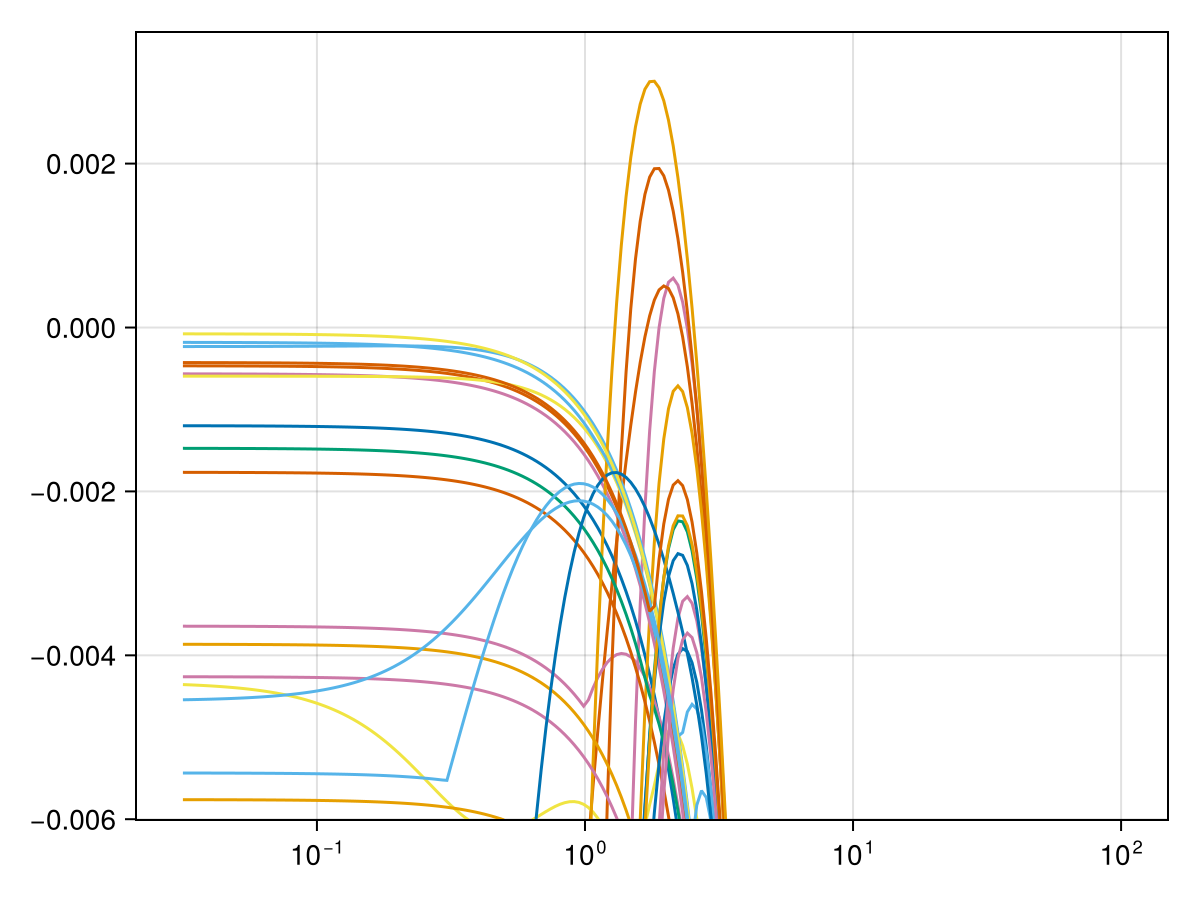

In [10]:
ks = 10 .^ range(-1.5, 2, 200)
DN = 1e-3
p = 1e1
(; Ds, mrls) = si_disprels(df, ks, DN, 1., p);

fig = Figure()
ax = Axis(fig[1,1]; xscale=log10)

for i in 1:nrow(df)
    if df.good[i]
        lines!(ks, mrls[i])
    end
end

mm = abs(maximum(maximum.(mrls[df.good])))
# xlims!(ax, 1e0, 1e2)
ylims!(ax, (-2., 1.2) .* mm)

fig

# Disprels ps, find a sensible system size and prep for PDE runs

In [39]:
num_systems = 60

# fully removing extinct species
remove_extinct = true
extinction_threshold = 1e-12

# disprels and peak finding
ks = 10 .^ range(-2, 2, 1000)  # grid the peak k gets read off, no root finding
ps = 10 .^ range(-2, 1, 4)          # byproduct diffusions (DR) to compare each system at
DN = 1e-3                      # strain diffusion
DI = 1.0                       # influx resource diffusion

# system size and spatial u0
num_peaks = 1    # peaks each domain fits; L is set per (system, p) from its own peak k
sN = 250         # spatial gridpoints, same for every run so dx varies with L
epsilon = 1e-2   # uniform, proportional +/- perturbation added to the ODE steady state
seed = 1         # so the u0s can be regenerated
T = T            # PDE end time, same as the ODE T in the section above

out_fname = "systems.jld2"

"systems.jld2"

In [29]:
if remove_extinct
    for r in eachrow(df)
        for i in 1:Ns
            if r.final_states[i] < extinction_threshold
                r.final_states[i] = 0.
            end
        end
    end
end

In [30]:
gdf = df[df.good, :]
gdf.df_row = findall(df.good) # which df row each one was, survives later filtering

(; mrls, peak_ks, peak_hs, at_edge) = disprel_peak_ks(gdf, ks, DN, DI, ps)

# peaks on the edge of the ks range are not real peaks - widen ks if any turn up
count(at_edge), count(ismissing, peak_ks), length(peak_ks)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:05

(0, 2975, 5640)

In [31]:
# Drop anything that is not spatially unstable at *every* p. `good` only says the
# well-mixed steady state is stable (that is the k=0 Jacobian), so a good system
# can still have no k>0 instability, and then there is no peak to size a domain
# to. Cutting them here means nothing downstream has to deal with missings.
keep = findall([all(!ismissing, peak_ks[i, :]) for i in 1:nrow(gdf)])
@show length(keep), nrow(gdf)
if !isnothing(num_systems)
    keep = keep[sample(1:length(keep), num_systems; replace=false)]
end;

gdf = gdf[keep, :]
mrls = mrls[keep, :]
peak_ks = disallowmissing(peak_ks[keep, :])
peak_hs = disallowmissing(peak_hs[keep, :])
at_edge = at_edge[keep, :]
nrow(gdf)

(length(keep), nrow(gdf)) = (72, 1410)

60

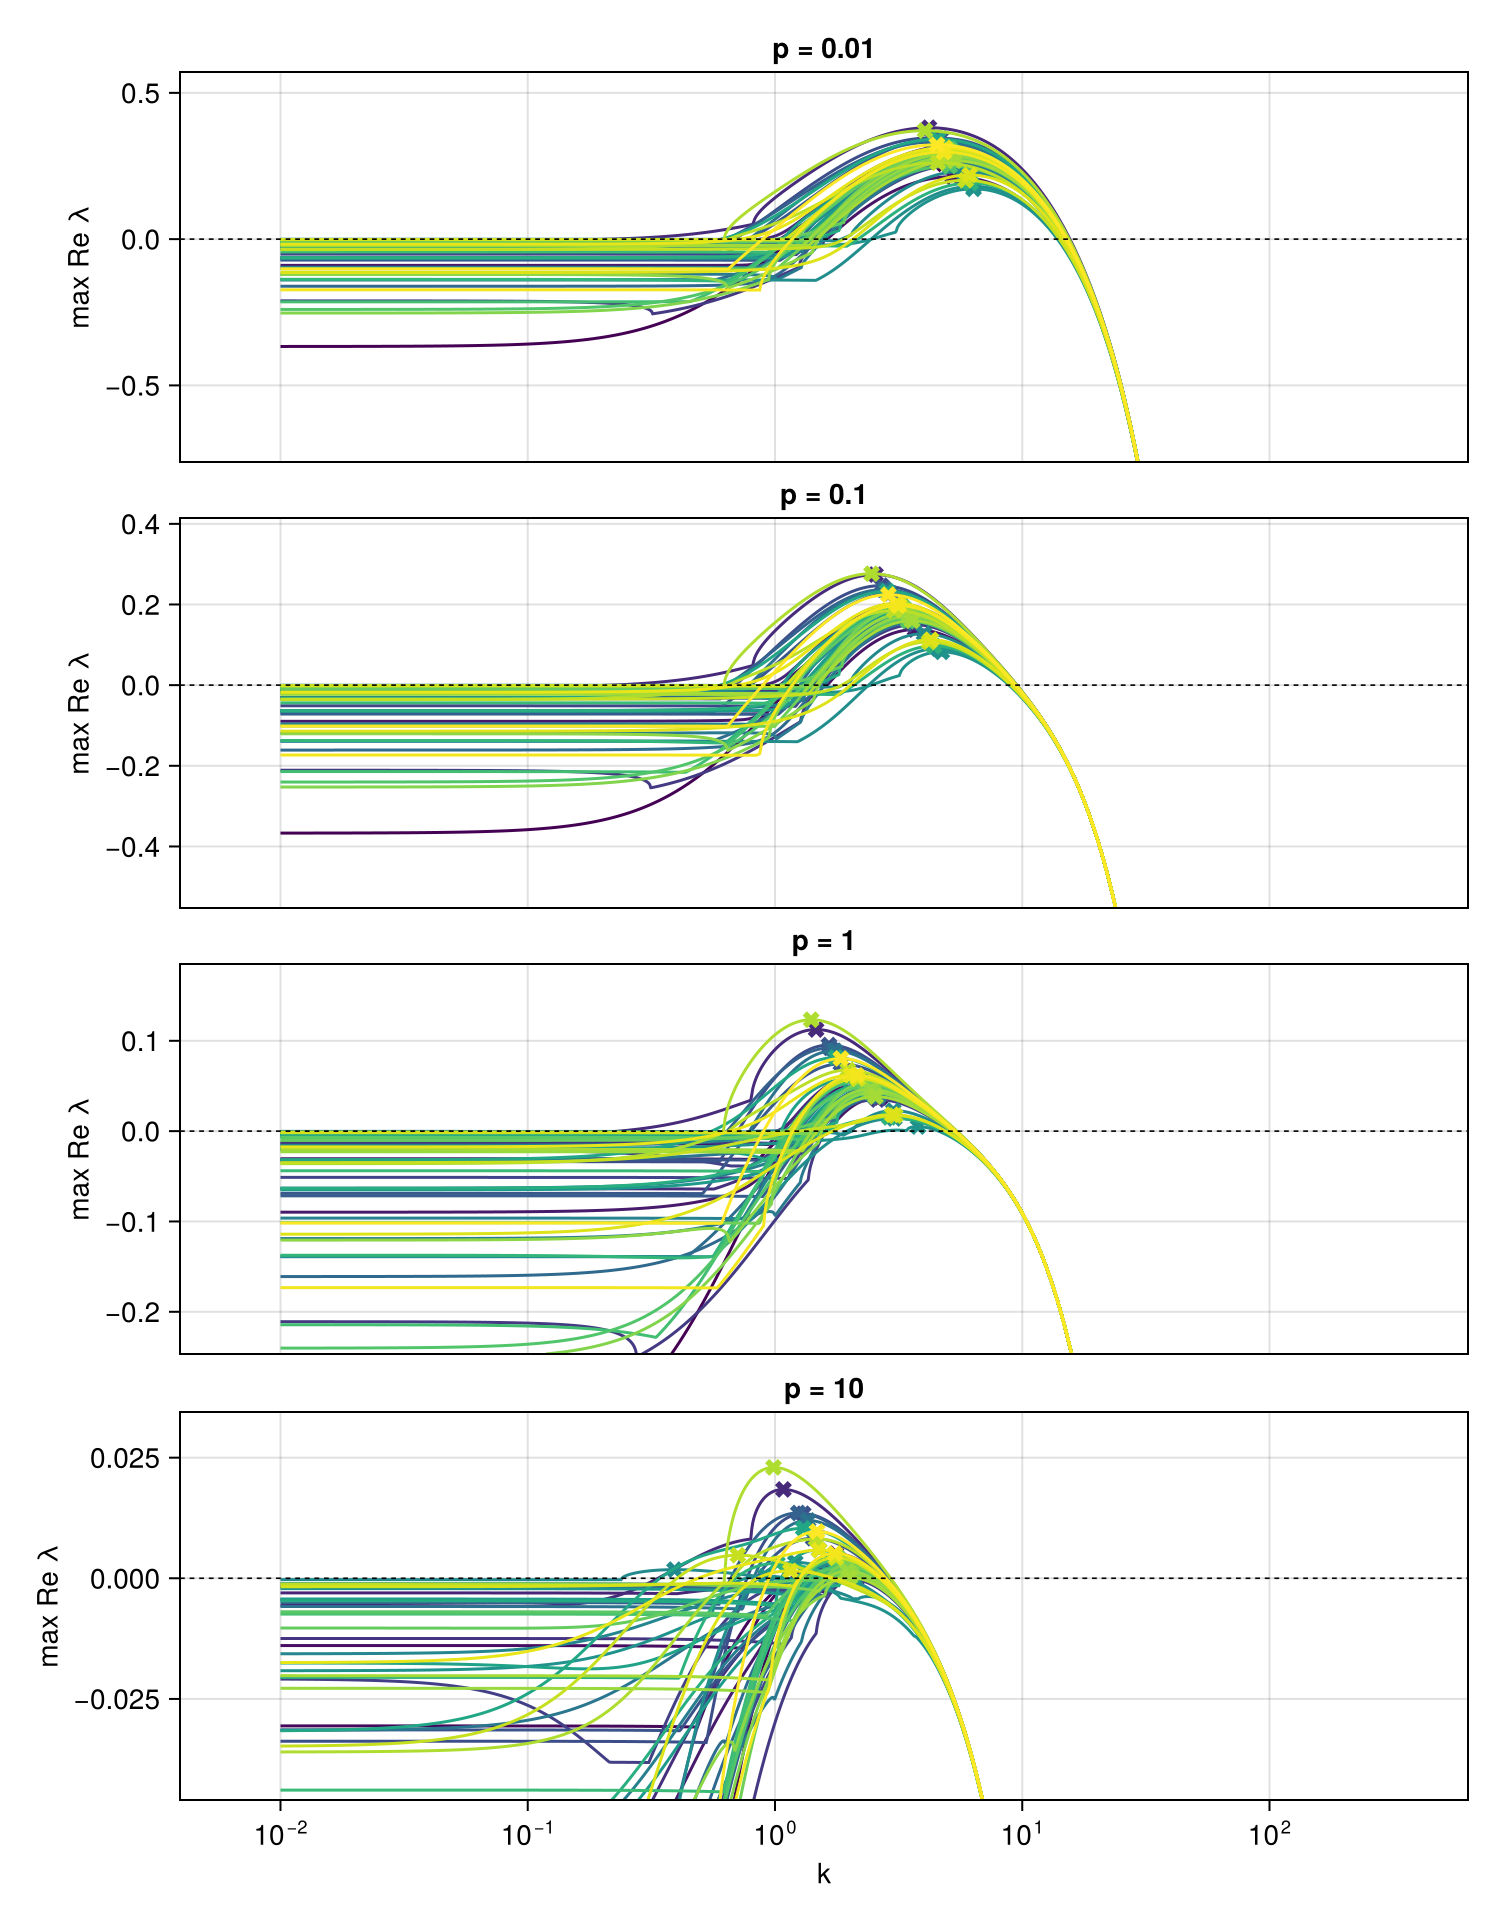

In [32]:
colors = Makie.resample_cmap(:viridis, max(nrow(gdf), 2))

fig = Figure(; size=(750, 240 * length(ps)))
axs = map(eachindex(ps)) do j
    Axis(fig[j, 1]; xscale=log10, ylabel="max Re λ", title=@sprintf("p = %g", ps[j]))
end
axs[end].xlabel = "k"

for j in eachindex(ps)
    for i in 1:nrow(gdf)
        lines!(axs[j], ks, mrls[i, j]; color=colors[i])
        scatter!(axs[j], [peak_ks[i, j]], [peak_hs[i, j]];
            color=colors[i], marker=:xcross, markersize=12)
    end
    hlines!(axs[j], 0.0; color=:black, linestyle=:dash, linewidth=0.8)
    mm = maximum(peak_hs[:, j]) # scale each panel by its own tallest peak
    ylims!(axs[j], -2mm, 1.5mm)
end

linkxaxes!(axs...)
# zoom onto where the peaks actually are rather than the whole scanned range
pkext = extrema(peak_ks)
# on all of them, not just the linked one - an axis left on autolimits pulls the
# whole link back out to the full ks range
xlims!.(axs, pkext[1] / 100, pkext[2] * 100)
hidexdecorations!.(axs[1:end-1]; grid=false)
rowgap!(fig.layout, 8)

fig

In [35]:
# One L per (system, p), each sized to fit exactly num_peaks peaks of that
# system's peak k at that p. Every run therefore starts with the same peak count
# and, since sN is shared, the same resolution per peak - only L differs.
Ls = choose_L.(peak_ks, num_peaks)

sizes_df = DataFrame(; df_row=gdf.df_row)
for j in eachindex(ps)
    sizes_df[!, @sprintf("k_p%g", ps[j])] = peak_ks[:, j]
    sizes_df[!, @sprintf("L_p%g", ps[j])] = Ls[:, j]
end
first(sizes_df, 10)

Row,df_row,k_p0.01,L_p0.01,k_p0.1,L_p0.1,k_p1,L_p1,k_p10,L_p10
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1158,4.81596,1.30466,3.23974,1.93941,2.19959,2.85652,1.76298,3.56397
2,1441,5.13701,1.22312,3.36145,1.86919,2.26128,2.7786,1.69914,3.69785
3,899,4.99688,1.25742,3.26975,1.92161,2.19959,2.85652,1.69914,3.69785
4,1344,5.23261,1.20077,3.6861,1.70456,2.66948,2.35371,2.13959,2.93663
5,1136,5.08987,1.23445,3.30003,1.90398,2.26128,2.7786,1.79578,3.49885
6,1206,4.99688,1.25742,3.21001,1.95737,2.19959,2.85652,1.7793,3.53126
7,1076,4.81596,1.30466,3.09379,2.0309,2.13959,2.93663,1.79578,3.49885
8,444,4.19394,1.49816,2.54921,2.46475,1.46611,4.28562,1.08152,5.80959
9,151,5.32999,1.17884,3.55263,1.7686,2.52582,2.48758,1.96922,3.1907


In [43]:
Random.seed!(seed)

# One u0 per system, shared by all of its p runs: the p comparison should not be
# confounded by each run starting from a different random perturbation. It only
# depends on sN and the ODE steady state, so the differing Ls do not enter here.
# The perturbation is proportional - uniform white noise on +/- epsilon * hss per
# field - so strains zeroed by the extinction filter stay at exactly 0 everywhere
# and cannot reinvade.
u0s = map(1:nrow(gdf)) do i
    Ns, Nr = get_Ns(gdf.params[i])
    perturb_u0_uniform_prop(Ns, Nr, expand_u0_to_size((sN,), gdf.final_states[i]), epsilon)
end

@show length(u0s) size(u0s[1])
# extinct fields must be identically zero across space
@show all(all(iszero, u0s[i][gdf.final_states[i].==0, :]) for i in eachindex(u0s))
@show minimum(minimum, u0s)
extrema(Ls ./ sN) # dx range

length(u0s) = 60
size(u0s[1]) = (40, 250)
all((all(iszero, (u0s[i])[gdf.final_states[i] .== 0, :]) for i = eachindex(u0s))) = true
minimum(minimum, u0s) = 0.0

(0.003957647017557885, 0.06406875224678428)

In [44]:
# One row per (system, p) - everything a PDE run needs bar the tolerances and
# maxtime, which are left to whoever runs it.
sysjs = [(i, j) for i in 1:nrow(gdf) for j in eachindex(ps)]

pde_df = DataFrame(;
    gdf_row=[i for (i, _) in sysjs],             # index into gdf / u0s
    df_row=[gdf.df_row[i] for (i, _) in sysjs],  # index into the original df
    p=[ps[j] for (_, j) in sysjs],
    params=[gdf.params[i] for (i, _) in sysjs],
    Ds=[make_si_Ds(gdf.params[i], DN, DI, ps[j]) for (i, j) in sysjs],
    L=[Ls[i, j] for (i, j) in sysjs],  # sized to num_peaks peaks of this (system, p)
    sN=fill(sN, length(sysjs)),
    T=fill(T, length(sysjs)),
    u0=[u0s[i] for (i, _) in sysjs],  # same array object across a system's ps
    mrls=[mrls[i, j] for (i, j) in sysjs],  # disprel on metadata.ks, handy to look at
)

metadata = (; K, l, ks, ps, DN, DI, num_peaks, sN, epsilon, seed)
jldsave(out_fname; metadata, pde_df)

@show nrow(pde_df) filesize(out_fname) / 1e6
select(pde_df, Not(:params, :Ds, :u0, :mrls)) # the big columns just spam the output

nrow(pde_df) = 240
filesize(out_fname) / 1.0e6 = 11.250417

Row,gdf_row,df_row,p,L,sN,T
,Int64,Int64,Float64,Float64,Int64,Float64
1,1,1158,0.01,1.30466,250,1.0e8
2,1,1158,0.1,1.93941,250,1.0e8
3,1,1158,1.0,2.85652,250,1.0e8
4,1,1158,10.0,3.56397,250,1.0e8
5,2,1441,0.01,1.22312,250,1.0e8
6,2,1441,0.1,1.86919,250,1.0e8
7,2,1441,1.0,2.7786,250,1.0e8
8,2,1441,10.0,3.69785,250,1.0e8
9,3,899,0.01,1.25742,250,1.0e8
